### Reason from multiple evidence

##### 1. Take the burglary example from the lecture as a basis and implement a Python class that enables to reason from any number of pieces of evidence. Provide appropriate methods to define the number of evidence pieces and input the required numbers. Ensure proper operation when some of the pieces of evidence are not present.

In [54]:
from typing import Dict, Optional

class NaiveBayesClassifier:
    def __init__(self, prior_intrusion: float):
        self.p_intrusion: float = prior_intrusion
        self.evidence: Dict[str, tuple[float, float]] = {}

    def add_evidence(self, name: str, p_given_intrusion: float, p_given_no_intrusion: float):
        self.evidence[name] = (p_given_intrusion, p_given_no_intrusion)

    def get_result(self, observed_evidence: Dict[str, Optional[bool]]):
        p_i = self.p_intrusion
        p_not_i = 1 - self.p_intrusion

        for name, observed in observed_evidence.items():
            if observed is None or name not in self.evidence:
                continue

            p_ai_i, p_ai_not_i = self.evidence[name]

            p_i *= p_ai_i if observed else (1 - p_ai_i)
            p_not_i *= p_ai_not_i if observed else (1 - p_ai_not_i)

        if (p_total := p_i + p_not_i) == 0:
            return 0.0

        return p_i / p_total


Cases from lecture

In [55]:
classifier = NaiveBayesClassifier(prior_intrusion=0.002)
classifier.add_evidence('alarm', p_given_intrusion=0.8, p_given_no_intrusion=0.01)
classifier.add_evidence('dog_barking', p_given_intrusion=0.98, p_given_no_intrusion=0.5)

print("Scenario 1")
result = classifier.get_result({'alarm': True, 'dog_barking': True})
print(f"P(burglary | alarm, dog_barking) = {result:.5f}")

print("\nScenario 2")
result = classifier.get_result({'alarm': True, 'dog_barking': False})
print(f"P(burglary | alarm, no dog_barking) = {result:.5f}")

print("\nScenario 3")
result = classifier.get_result({'alarm': False, 'dog_barking': True})
print(f"P(burglary | no alarm, dog_barking) = {result:.5f}")

Scenario 1
P(burglary | alarm, dog_barking) = 0.23910

Scenario 2
P(burglary | alarm, no dog_barking) = 0.00637

Scenario 3
P(burglary | no alarm, dog_barking) = 0.00079


##### 2. Play with the class, plot output for different combinations of inputs. 

Ile psów potrzeba żebyśmy taką samą pewność jak przy samym alarmie?

Przy 1 nieszczekającym psie

Only alarm
P(burglary | alarm) = 0.13817

Only dogs
P(burglary | 0 dogs barking, 1 dog not barking) = 0.00008
P(burglary | 1 dogs barking, 1 dog not barking) = 0.00016
P(burglary | 2 dogs barking, 1 dog not barking) = 0.00031
P(burglary | 3 dogs barking, 1 dog not barking) = 0.00060
P(burglary | 4 dogs barking, 1 dog not barking) = 0.00118
P(burglary | 5 dogs barking, 1 dog not barking) = 0.00231
P(burglary | 6 dogs barking, 1 dog not barking) = 0.00452
P(burglary | 7 dogs barking, 1 dog not barking) = 0.00883
P(burglary | 8 dogs barking, 1 dog not barking) = 0.01716
P(burglary | 9 dogs barking, 1 dog not barking) = 0.03309
P(burglary | 10 dogs barking, 1 dog not barking) = 0.06285
P(burglary | 11 dogs barking, 1 dog not barking) = 0.11618
P(burglary | 12 dogs barking, 1 dog not barking) = 0.20487 -> More likely with dogs barking than with alarm alone
P(burglary | 13 dogs barking, 1 dog not barking) = 0.33555
P(burglary | 14 dogs barking, 1 dog not barking) = 0.49744
P(burglary | 15 do

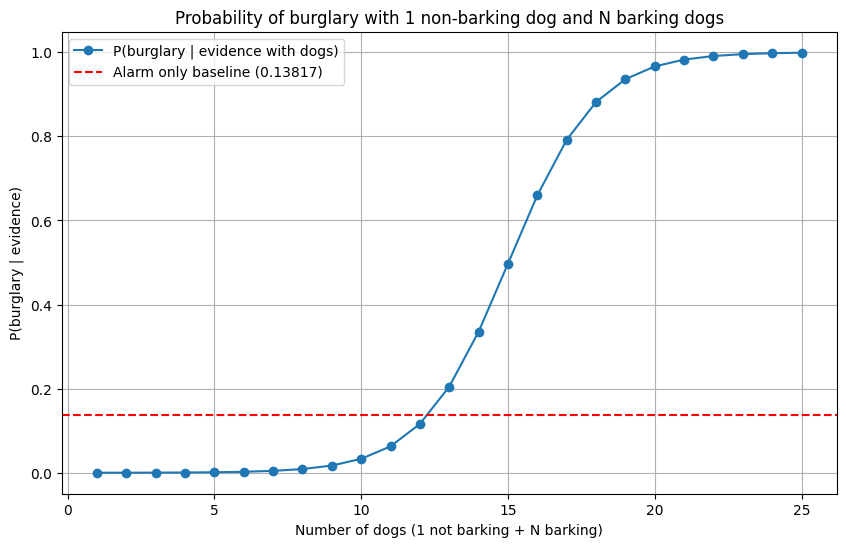

In [63]:
import matplotlib.pyplot as plt

classifier_alarm = NaiveBayesClassifier(prior_intrusion=0.002)
classifier_alarm.add_evidence('alarm', p_given_intrusion=0.8, p_given_no_intrusion=0.01)

print("Only alarm")
result_alarm = classifier_alarm.get_result({'alarm': True})
print(f"P(burglary | alarm) = {result_alarm:.5f}")

print('\nOnly dogs', end='')
classifier_dogs = NaiveBayesClassifier(prior_intrusion=0.002)
is_more_likely = False
result_dogs = []
dogs_evidence = {f'dog_barking-{i}': None for i in range(10)}
for i in range(25):
    classifier_dogs.add_evidence(f'dog_barking-{i}', p_given_intrusion=0.98, p_given_no_intrusion=0.5)
    if i == 0:
        dogs_evidence[f'dog_barking-{i}'] = False
    else:
        dogs_evidence[f'dog_barking-{i}'] = True
    result = classifier_dogs.get_result({'alarm': False, **dogs_evidence})
    result_dogs.append(result)
    print(f"\nP(burglary | {i} dogs barking, 1 dog not barking) = {result:.5f}", end='')
    if result > result_alarm and not is_more_likely:
        print(" -> More likely with dogs barking than with alarm alone", end='')
        is_more_likely = True

plt.figure(figsize=(10, 6))
plt.plot(range(1, 26), result_dogs, marker='o', label='P(burglary | evidence with dogs)')
plt.axhline(y=result_alarm, color='r', linestyle='--', label=f'Alarm only baseline ({result_alarm:.5f})')
plt.xlabel('Number of dogs (1 not barking + N barking)')
plt.ylabel('P(burglary | evidence)')
plt.title('Probability of burglary with 1 non-barking dog and N barking dogs')
plt.legend()
plt.grid(True)
plt.show()


Przy wszystkich szczekających

Only alarm
P(burglary | alarm) = 0.13817

Only dogs
P(burglary | 1 dogs barking) = 0.00391
P(burglary | 2 dogs barking) = 0.00764
P(burglary | 3 dogs barking) = 0.01486
P(burglary | 4 dogs barking) = 0.02873
P(burglary | 5 dogs barking) = 0.05479
P(burglary | 6 dogs barking) = 0.10202
P(burglary | 7 dogs barking) = 0.18213 -> More likely with dogs barking than with alarm alone
P(burglary | 8 dogs barking) = 0.30385
P(burglary | 9 dogs barking) = 0.46105
P(burglary | 10 dogs barking) = 0.62641
P(burglary | 11 dogs barking) = 0.76670
P(burglary | 12 dogs barking) = 0.86561
P(burglary | 13 dogs barking) = 0.92661
P(burglary | 14 dogs barking) = 0.96116
P(burglary | 15 dogs barking) = 0.97980
P(burglary | 16 dogs barking) = 0.98959
P(burglary | 17 dogs barking) = 0.99466
P(burglary | 18 dogs barking) = 0.99727
P(burglary | 19 dogs barking) = 0.99860
P(burglary | 20 dogs barking) = 0.99929
P(burglary | 21 dogs barking) = 0.99964
P(burglary | 22 dogs barking) = 0.99981
P(burglary | 23 dogs b

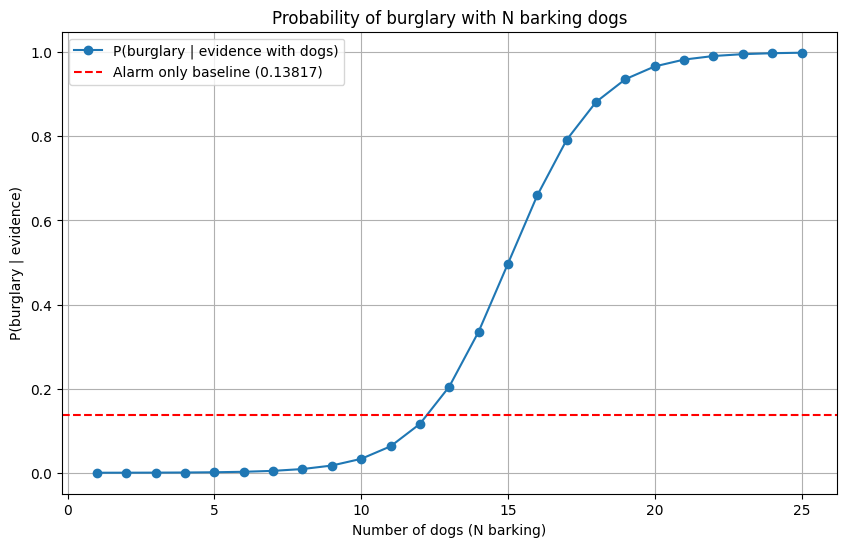

In [64]:
classifier_alarm = NaiveBayesClassifier(prior_intrusion=0.002)
classifier_alarm.add_evidence('alarm', p_given_intrusion=0.8, p_given_no_intrusion=0.01)

print("Only alarm")
result_alarm = classifier_alarm.get_result({'alarm': True})
print(f"P(burglary | alarm) = {result_alarm:.5f}")

print('\nOnly dogs', end='')
classifier_dogs = NaiveBayesClassifier(prior_intrusion=0.002)
is_more_likely = False
dogs_evidence = {f'dog_barking-{i}': None for i in range(10)}
for i in range(25):
    classifier_dogs.add_evidence(f'dog_barking-{i}', p_given_intrusion=0.98, p_given_no_intrusion=0.5)
    dogs_evidence[f'dog_barking-{i}'] = True
    result = classifier_dogs.get_result({'alarm': False, **dogs_evidence})
    print(f"\nP(burglary | {i+1} dogs barking) = {result:.5f}", end='')
    if result > result_alarm and not is_more_likely:
        print(" -> More likely with dogs barking than with alarm alone", end='')
        is_more_likely = True

plt.figure(figsize=(10, 6))
plt.plot(range(1, 26), result_dogs, marker='o', label='P(burglary | evidence with dogs)')
plt.axhline(y=result_alarm, color='r', linestyle='--', label=f'Alarm only baseline ({result_alarm:.5f})')
plt.xlabel('Number of dogs (N barking)')
plt.ylabel('P(burglary | evidence)')
plt.title('Probability of burglary with N barking dogs')
plt.legend()
plt.grid(True)
plt.show()


P(włamianie | siła alarmu)

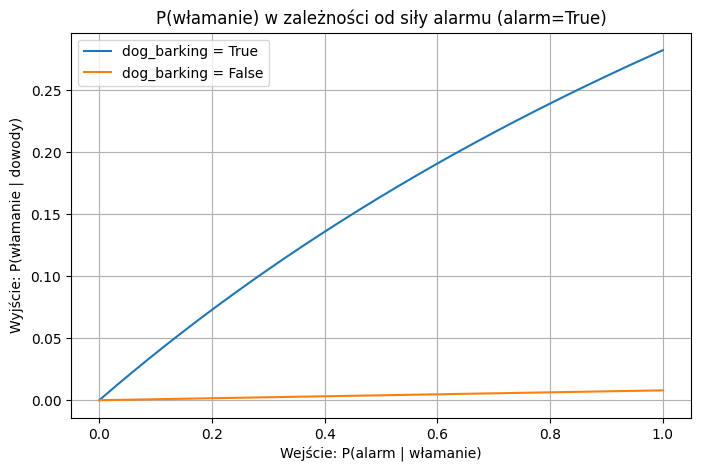

In [58]:
import numpy as np

import matplotlib.pyplot as plt

p_vals = np.linspace(0, 1, 201)

prior = classifier.p_intrusion
alarm_p_not_i = classifier.evidence['alarm'][1]        
dog_p_i, dog_p_not_i = classifier.evidence['dog_barking']

y_dog_true = []
y_dog_false = []

for p_alarm_i in p_vals:
    c = NaiveBayesClassifier(prior_intrusion=prior)
    c.add_evidence('alarm', p_given_intrusion=p_alarm_i, p_given_no_intrusion=alarm_p_not_i)
    c.add_evidence('dog_barking', p_given_intrusion=dog_p_i, p_given_no_intrusion=dog_p_not_i)

    y_dog_true.append(c.get_result({'alarm': True, 'dog_barking': True}))
    y_dog_false.append(c.get_result({'alarm': True, 'dog_barking': False}))

plt.figure(figsize=(8,5))
plt.plot(p_vals, y_dog_true, label='dog_barking = True')
plt.plot(p_vals, y_dog_false, label='dog_barking = False')
plt.xlabel('Wejście: P(alarm | włamanie)')
plt.ylabel('Wyjście: P(włamanie | dowody)')
plt.title('P(włamanie) w zależności od siły alarmu (alarm=True)')
plt.legend()
plt.grid(True)
plt.show()

##### 3. Going back to the example, consider situation when the alarm is not silent – it blares horn and flashes light when it goes off. Can computations still be performed in the same manner? Explain.

W przypadku kiedy zamieniamy alarm na 2 zdarzenia - syrenę alarmową i światła ostrzegawcze mamy 3 zdarzenia, łącznie ze szczekaniem psa. Jednak ważnym warunkiem jest to że zdarzenia muszą być od siebie niezależne. Więc w przypadku, gdy alarm emituje jednocześnie dźwięk i światło, oba te sygnały są konsekwencją jednego zdarzenia („alarm się włączył”), więc nie są od siebie niezależne.